<a href="https://colab.research.google.com/github/sovandyros/UBTW/blob/main/Lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IE 332 - Lab 3: SQL and ERD Practice

**Name:**  
**Lab section:**  

## Goals

1. Use SQL to join tables and calculate grouped totals.
2. Use `HAVING` to filter grouped results.
3. Use a CTE to compare grouped results with a calculated average.
4. Explain what each row represents, identify keys, and draw an entity-relationship diagram (ERD).


## Section 0 - Setup

Run the next cell and upload `boilermaker_brews.db` when prompted. The database file is on Brightspace.

Use `%%sql` as in Lab 2. Keep the first line of each exercise cell, such as `%%sql q1 <<`, and write your SQL below it. The cell displays the result and saves it as `q1` for the provided self-check. You do not need to write Python code.


In [4]:
# Run this setup cell as provided. No package installation is needed.
from pathlib import Path
import sqlite3
import pandas as pd
from IPython.display import display

DB_PATH = Path("boilermaker_brews.db")

if not DB_PATH.exists():
    try:
        from google.colab import files
    except ImportError as exc:
        raise FileNotFoundError(
            "Place boilermaker_brews.db in the notebook's working folder."
        ) from exc
    print("Choose boilermaker_brews.db from the course files.")
    files.upload()

if not DB_PATH.exists():
    raise FileNotFoundError("boilermaker_brews.db was not uploaded.")

# These exercises only read data; protect the uploaded database from changes.
conn = sqlite3.connect(DB_PATH.resolve().as_uri() + "?mode=ro", uri=True)


class SQLResult(list):
    """Query rows and the information needed by the provided self-checks."""
    def __init__(self, frame, sql):
        super().__init__(frame.itertuples(index=False, name=None))
        self.keys = list(frame.columns)
        self.frame = frame
        self.sql = sql


def _sql_magic(line, cell):
    """Run SQL and display its result; %%sql q1 << also saves it as q1."""
    parts = line.split()
    if parts and (
        not parts[0].isidentifier()
        or len(parts) > 2
        or (len(parts) == 2 and parts[1] != "<<")
    ):
        raise ValueError("Use %%sql or a capture header such as %%sql q1 <<.")
    target = parts[0] if parts else None
    if target:
        # A failed rerun must not leave an earlier answer available to the check.
        get_ipython().user_ns[target] = None
    with conn:
        cursor = conn.execute(cell)
        if cursor.description is None:
            raise ValueError("Write a SELECT or WITH query below the %%sql header.")
        frame = pd.DataFrame(cursor.fetchall(), columns=[col[0] for col in cursor.description])
    if target:
        get_ipython().user_ns[target] = SQLResult(frame, cell)
    display(frame)


get_ipython().register_magic_function(_sql_magic, "cell", "sql")


def _sql_line_magic(line):
    _sql_magic("", line)


get_ipython().register_magic_function(_sql_line_magic, "line", "sql")
print(f"Connected to {DB_PATH.name}. The %%sql command is ready.")


Connected to boilermaker_brews.db. The %%sql command is ready.


**Load the self-checks.** Run the next cell once.

In [5]:
# Run this cell once, then run each check after its exercise.
import re

def _require_result(value, label):
    assert isinstance(value, SQLResult), (
        f"Run the SQL cell with the header %%sql {label} << successfully before checking."
    )
    return value.frame

def _require_columns(frame, expected):
    actual = list(frame.columns)
    assert actual == expected, f"Expected columns {expected}, got {actual}."

def _rounded(values):
    return [round(float(value), 2) for value in values]

def check_q1(result):
    frame = _require_result(result, "q1")
    _require_columns(frame, ["category", "revenue"])
    expected_categories = ["espresso", "brew", "tea", "pastry", "food", "merch"]
    expected_revenue = [197025.25, 67355.30, 44795.50, 39935.30, 21793.25, 3310.00]
    assert frame["category"].tolist() == expected_categories, (
        "Expected all six categories ordered by revenue from highest to lowest."
    )
    assert _rounded(frame["revenue"]) == expected_revenue, (
        "Revenue values are incorrect. Include quantity * unit_price before summing."
    )
    print("[OK] Q1 - All six category revenues are correct and ordered from highest to lowest.")

def check_q2(result):
    frame = _require_result(result, "q2")
    sql_text = result.sql
    _require_columns(frame, ["category", "revenue"])
    assert re.search(r"\bHAVING\b", sql_text, flags=re.IGNORECASE), (
        "Use HAVING to filter the completed category groups."
    )
    expected_categories = ["espresso", "brew", "tea"]
    expected_revenue = [197025.25, 67355.30, 44795.50]
    assert frame["category"].tolist() == expected_categories, (
        "Expected espresso, brew, and tea ordered by revenue from highest to lowest."
    )
    assert _rounded(frame["revenue"]) == expected_revenue, (
        "The category revenue values are incorrect."
    )
    print("[OK] Q2 - HAVING kept the three categories with revenue above $40,000.")

def check_q3(result):
    frame = _require_result(result, "q3")
    sql_text = result.sql
    _require_columns(frame, ["name", "revenue"])
    assert re.search(r"\bWITH\b", sql_text, flags=re.IGNORECASE), (
        "Use a CTE introduced with WITH."
    )
    assert re.search(r"\bAVG\s*\(", sql_text, flags=re.IGNORECASE), (
        "Compare each product total with AVG(revenue) from the CTE."
    )
    expected_names = [
        "Caramel Latte", "Mocha", "Latte 12oz", "Peppermint Mocha",
        "Nitro Cold Brew", "Latte 16oz", "Pumpkin Spice Latte",
        "Cold Brew 16oz", "Cappuccino", "Drip Coffee 16oz",
    ]
    expected_revenue = [
        30791.25, 29373.75, 25519.50, 25449.50, 22814.55,
        21705.00, 20774.75, 19554.25, 16154.25, 15444.00,
    ]
    assert frame["name"].tolist() == expected_names, (
        "Expected products with above-average total revenue, ordered by revenue."
    )
    assert _rounded(frame["revenue"]) == expected_revenue, "One or more revenue values are incorrect."
    print("[OK] Q3 - 10 products exceed the average product revenue of $14,392.87.")

print("Checks loaded.")


Checks loaded.


## Section 1 - SQL practice

### Q1. Revenue by category

Use SQL to calculate total revenue for each product category. Each sale line contributes its quantity multiplied by its recorded unit price.

- Return exactly two columns named `category` and `revenue`.
- Return all six categories, ordered by revenue from highest to lowest.
- Keep the `%%sql q1 <<` header to save the result for the self-check.


In [6]:
%%sql q1 <<
SELECT p.category,
       SUM(oi.quantity * oi.unit_price) AS revenue
FROM order_items oi
JOIN products p
    ON oi.product_id = p.product_id
GROUP BY p.category
ORDER BY revenue DESC;


,category,revenue
0,espresso,197025.25
1,brew,67355.30
2,tea,44795.50
3,pastry,39935.30
4,food,21793.25
5,merch,3310.00


In [7]:
check_q1(q1)


[OK] Q1 - All six category revenues are correct and ordered from highest to lowest.


### Q2. Filter category totals with `HAVING`

Modify the Q1 query so that it returns only categories whose total revenue exceeds $40,000.

- Use `HAVING` for the total-revenue condition.
- Return exactly two columns named `category` and `revenue`.
- Order the result by revenue from highest to lowest.
- Keep the `%%sql q2 <<` header to save the result for the self-check.


In [10]:
%%sql q2 <<
SELECT p.category,
       SUM(oi.quantity * oi.unit_price) AS revenue
FROM order_items oi
JOIN products p
    ON oi.product_id = p.product_id
GROUP BY p.category
HAVING SUM(oi.quantity * oi.unit_price) > 40000
ORDER BY revenue DESC;


,category,revenue
0,espresso,197025.25
1,brew,67355.30
2,tea,44795.50


In [11]:
check_q2(q2)


[OK] Q2 - HAVING kept the three categories with revenue above $40,000.


### Q3. Products with above-average total revenue

Calculate total revenue for each product. Return products whose total exceeds the average of those totals. All 26 products have recorded sales, so include all 26 product totals when calculating the average.

- Use a common table expression (CTE) and `AVG`.
- Return exactly `name` and `revenue`, ordered by revenue from highest to lowest. Keep the `%%sql q3 <<` header to save the result for the self-check.
- Use the average comparison, not `LIMIT`, to select products.


In [15]:
%%sql q3 <<
WITH product_revenue AS (
    SELECT p.product_id,
           p.name,
           SUM(oi.quantity * oi.unit_price) AS revenue
    FROM products p
    JOIN order_items oi
        ON p.product_id = oi.product_id
    GROUP BY p.product_id, p.name
)

SELECT name, revenue
FROM product_revenue
WHERE revenue > (SELECT AVG(revenue) FROM product_revenue)
ORDER BY revenue DESC;

,name,revenue
0,Caramel Latte,30791.25
1,Mocha,29373.75
2,Latte 12oz,25519.50
3,Peppermint Mocha,25449.50
4,Nitro Cold Brew,22814.55
5,Latte 16oz,21705.00
6,Pumpkin Spice Latte,20774.75
7,Cold Brew 16oz,19554.25
8,Cappuccino,16154.25
9,Drip Coffee 16oz,15444.00


In [16]:
check_q3(q3)


[OK] Q3 - 10 products exceed the average product revenue of $14,392.87.


## Section 2 - Rows and keys

Use the Boilermaker Brews data dictionary on Brightspace.

**R1.** Complete each statement:

- One row of `orders` represents ...
- One row of `order_items` represents ...

**R2.** State the two-column primary key of `order_items`. Explain why `order_id` alone is not unique and why `product_id` alone is not unique.

**Your response:**  
R1.  
R2.


## Section 3 - ERD practice: Food Truck Friday

Design a database with these tables:

- `trucks`: `truck_id`, `name`, `cuisine`
- `spots`: `spot_id`, `location`
- `assignments`: `truck_id`, `friday_date`, `spot_id`

Truck IDs and spot IDs uniquely identify trucks and spots. Each assignment records one truck's spot on one Friday.

**Rules**

- On each Friday that a truck participates, it has exactly one spot. Its spot may change between Fridays.
- A spot may host zero, one, or many trucks on the same Friday.
- Truck and spot records may exist before they have any assignments.

**D1. Choose the key.** State what one row of `assignments` represents. Choose the smallest set of columns that uniquely identifies it, and use that set as the primary key. Explain why the Friday date is needed. Do not add an `assignment_id`.

**D2. Draw the ERD.**

- Show all three tables and their listed attributes. Mark each primary key (PK) and foreign key (FK), using your D1 key for `assignments`.
- Connect each FK field to its referenced PK field with a line without arrows. Label both ends with multiplicities. Each label states how many rows of that table are allowed for one row at the other end.
- Link `trucks` and `spots` through `assignments`, without an extra direct line between them.
- Explain whether trucks and spots have a many-to-many relationship over time.

**Format.** Include a readable image of a hand-drawn or digital ERD. If you cannot embed an image during lab, provide a complete text schema and relationship list instead.


## Your responses

**D1. Row meaning, primary key, and explanation:**  

**D2. ERD or complete text equivalent:**  

**Trucks and spots over time:**


### Add your ERD image

Upload a JPG or PNG and set `ERD_FILE` below to its filename. If you provided the complete text alternative, leave the filename unchanged.


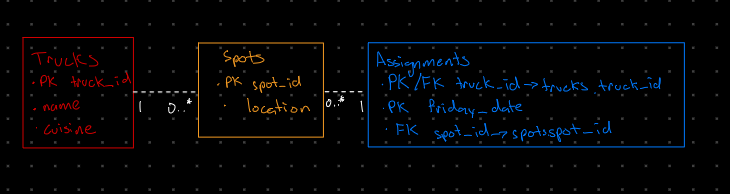

In [18]:
ERD_FILE = Path("my_erd.png")  # Change this after uploading your image.

if ERD_FILE.exists():
    from IPython.display import Image, display
    display(Image(filename=str(ERD_FILE), width=700))
else:
    print("No ERD image displayed. Include the complete text alternative above if needed.")

## Before submitting

- Complete Q1-Q3, R1-R2, and D1-D2.
- Run the self-checks and use their feedback. If you remain stuck, keep your attempt and briefly explain the difficulty.
- Restart the runtime and run the cells from top to bottom. If a check fails, continue with the remaining cells. Confirm that your outputs, written answers, and ERD image or text alternative are visible.
- Submit the `.ipynb` and a PDF showing your work to Gradescope by **Sunday at 11:59 p.m.**

A genuine attempt at every required item earns completion credit.
